# Carga del dataset

In [1]:
import kagglehub

path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


In [2]:
import os
dataset_path = path + '/Data'

non_demented_path = os.path.join(dataset_path, 'Non Demented')
moderate_demented_path = os.path.join(dataset_path, 'Moderate Dementia')
mild_demented_path = os.path.join(dataset_path, 'Mild Dementia')
very_mild_demented_path = os.path.join(dataset_path, 'Very mild Dementia')

non_demented_images = [os.path.join(non_demented_path, file) for file in os.listdir(non_demented_path) if file.endswith('.jpg')]
moderate_demented_images = [os.path.join(moderate_demented_path, file) for file in os.listdir(moderate_demented_path) if file.endswith('.jpg')]
mild_demented_images = [os.path.join(mild_demented_path, file) for file in os.listdir(mild_demented_path) if file.endswith('.jpg')]
very_mild_demented_images = [os.path.join(very_mild_demented_path, file) for file in os.listdir(very_mild_demented_path) if file.endswith('.jpg')]

from sklearn.model_selection import train_test_split
non_demented_train, non_demented_test = train_test_split(non_demented_images, test_size=0.2, random_state=42)
moderate_demented_train, moderate_demented_test = train_test_split(moderate_demented_images, test_size=0.2, random_state=42)
mild_demented_train, mild_demented_test = train_test_split(mild_demented_images, test_size=0.2, random_state=42)
very_mild_demented_train, very_mild_demented_test = train_test_split(very_mild_demented_images, test_size=0.2, random_state=42)

print(len(non_demented_train), len(moderate_demented_train), len(mild_demented_train), len(very_mild_demented_train))

import random
target_samples = 3000

moderate_demented_sample = random.choices(moderate_demented_train, k=target_samples)
mild_demented_sample = random.choices(mild_demented_train, k=target_samples)

very_mild_demented_sample = random.sample(very_mild_demented_train, target_samples)
non_demented_sample = random.sample(non_demented_train, target_samples)

print(len(non_demented_test), len(moderate_demented_test), len(mild_demented_test), len(very_mild_demented_test))

target_samples = 640
mild_demented_test = random.sample(mild_demented_test, target_samples)
non_demented_test = random.sample(non_demented_test, target_samples)
very_mild_demented_test = random.sample(very_mild_demented_test, target_samples)


53777 390 4001 10980
13445 98 1001 2745


In [3]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit([[0], [1], [2], [3]])

from PIL import Image
import numpy as np
data = []
result = []

for image in non_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[3]]).toarray())

print("End 4")

data = np.array(data, dtype='float32') / 255.0

data.shape

result = np.array(result)
result = np.array(result, dtype='float32')
result = result.reshape((result.shape[0],4))
print(result.shape)

X_train, x_val, y_train, y_val = train_test_split(data, result, test_size=0.2, random_state=42)


End 1
End 2
End 3
End 4
(12000, 4)


In [4]:
data_test = []
result_test = []

for image in non_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[3]]).toarray())

print("End 4")

data_test = np.array(data_test, dtype='float32')/255

data_test.shape

result_test = np.array(result_test, dtype='float32')
result_test = result_test.reshape((result_test.shape[0],4))
result_test.shape

X_test = data_test
y_test = result_test


End 1
End 2
End 3
End 4


# Modelos Preentrenados

## Entrenamiento con fine tunning utilizando ResNet50

Entrenamos el modelo ResNet50 utilizando el conjunto de datos de entrenamiento aplicandole diferentes callbacks y utilizando fine tunning.

In [6]:
import tensorflow as tf
import keras
import keras_hub

M = keras_hub.models.ImageClassifier.from_preset('resnet_vd_50_ssld_v2_imagenet', num_classes=4, activation='softmax', dropout=0.0)
M.layers[1].trainable = True
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
M.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
reduce_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5)
early_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
H = M.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(x_val, y_val), callbacks=[reduce_cb, early_cb])


Epoch 1/100


I0000 00:00:1760543920.816671      94 service.cc:148] XLA service 0x7d0bfc002f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760543920.817646      94 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760543924.479222      94 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1760543942.656696      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


300/300 ━━━━━━━━━━━━━━━━━━━━ 122s 201ms/step - accuracy: 0.7280 - loss: 0.6319 - val_accuracy: 0.3979 - val_loss: 1.9633 - learning_rate: 1.0000e-04
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.9412 - loss: 0.1656 - val_accuracy: 0.2554 - val_loss: 7.9686 - learning_rate: 1.0000e-04
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.9710 - loss: 0.0847 - val_accuracy: 0.3304 - val_loss: 4.5161 - learning_rate: 1.0000e-04
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.9805 - loss: 0.0529 - val_accuracy: 0.3617 - val_loss: 4.1723 - learning_rate: 1.0000e-04
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.9826 - loss: 0.0443 - val_accuracy: 0.2688 - val_loss: 5.3962 - learning_rate: 1.0000e-04
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.9826 - loss: 0.0512 - val_accuracy: 0.3350 - val_loss: 3.8822 - learning_rate: 1.0000e-04
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/

## Resultados de ResNet50 con fine tunning

Tras realizar el entrenamiento, se ha utilizado el conjunto de pruebas para evaluar la precisión del modelo. Con el conjunto de pruebas se ha obtenido una precisión del 98,91%. La más alta hasta el momento.

In [7]:
acc_train = M.evaluate(X_train, y_train, verbose=0)[1]
acc_val = M.evaluate(x_val, y_val, verbose=0)[1]
print(f'Precisiones train-val: {acc_train:.2%} {acc_val:.2%}')

Precisiones train-val: 100.00% 98.67%


In [8]:
acc_test = M.evaluate(X_test, y_test, verbose=0)[1]
print(f'Precision test: {acc_test:.2%}')


Precision test: 98.91%


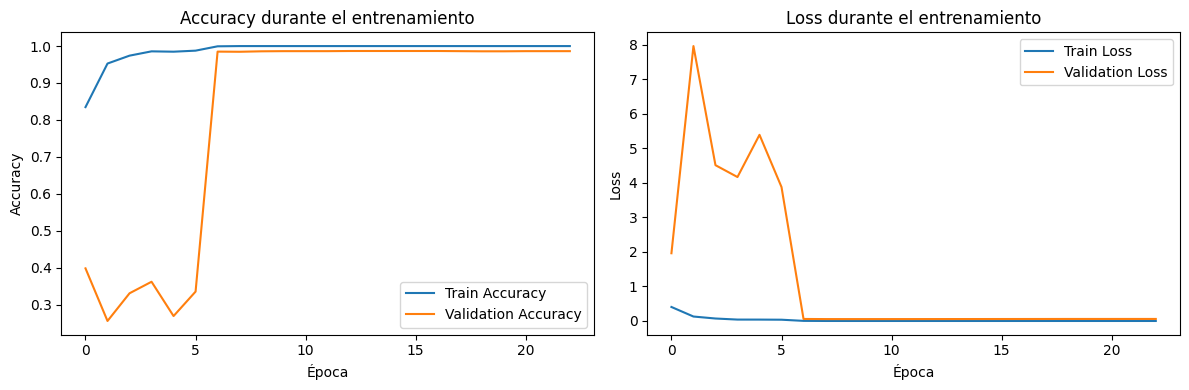

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(H.history['accuracy'], label='Train Accuracy')
plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(H.history['loss'], label='Train Loss')
plt.plot(H.history['val_loss'], label='Validation Loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

plt.savefig("entrenamiento_metrics.png", dpi=300)

plt.show()


## ResNet50 con fine tunning y ampliación de datos

In [9]:
import tensorflow as tf
import keras
import keras_hub
factor = 2.0/32.0
preprocessor = keras.layers.Pipeline([keras.layers.RandomFlip('horizontal'),
 keras.layers.RandomTranslation(factor, factor, interpolation='nearest'),
 keras.layers.Rescaling(1.0 / 255)])

M2 = keras_hub.models.ImageClassifier.from_preset('resnet_vd_50_ssld_v2_imagenet', num_classes=4, activation='softmax', dropout=0.0)
M2.layers[1].trainable = True
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
M2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
reduce_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5)
early_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
H = M2.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(x_val, y_val), callbacks=[reduce_cb, early_cb])


Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 123s 208ms/step - accuracy: 0.7247 - loss: 0.6371 - val_accuracy: 0.4921 - val_loss: 1.9032 - learning_rate: 1.0000e-04
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.9387 - loss: 0.1632 - val_accuracy: 0.3846 - val_loss: 5.3986 - learning_rate: 1.0000e-04
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 192ms/step - accuracy: 0.9728 - loss: 0.0810 - val_accuracy: 0.2521 - val_loss: 4.2584 - learning_rate: 1.0000e-04
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.9802 - loss: 0.0535 - val_accuracy: 0.2558 - val_loss: 8.2817 - learning_rate: 1.0000e-04
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.9891 - loss: 0.0321 - val_accuracy: 0.2604 - val_loss: 7.9029 - learning_rate: 1.0000e-04
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.9879 - loss: 0.0350 - val_accuracy: 0.3413 - val_loss: 6.0736 - learning_rate: 1.0000e-04
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━

Aplicar el aumento de datos a imágenes cerebrales puede ser una mala opción debido a que pueden distorsionar la estructura real del cerebro y podría alterar regiones del cerebro importantes para la detección del alzheimer. Tras realizar el entrenamiento, se ha probado el conjunto de test y se ha obtenido una peor precisión que el anterior modelo. La precisión obtenida ha sido del 98,32%

In [10]:
acc_train = M2.evaluate(X_train, y_train, verbose=0)[1]
acc_val = M2.evaluate(x_val, y_val, verbose=0)[1]
print(f'Precisiones train-val: {acc_train:.2%} {acc_val:.2%}')

Precisiones train-val: 100.00% 98.67%


In [11]:
acc_test = M2.evaluate(X_test, y_test, verbose=0)[1]
print(f'Precisiones train-val: {acc_test:.2%}')


Precisiones train-val: 98.32%


## Modelo EfficientNetB2

Se ha probado un modelo diferente al de ResNet50 para probar diferentes modelos. Con este modelo aplicandole fine tunning se ha obtenido una precisión del 98,22% en el conjunto de tests.

In [13]:
from keras_hub.models import ImageClassifier

M = ImageClassifier.from_preset("efficientnet_b2_ra_imagenet", num_classes=4, activation="softmax", dropout=0.2)

M.summary()


Preprocessor: "efficient_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficient_net_image_converter (EfficientNetImageConverter)    │                   Image size: (256, 256) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "efficient_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)                    │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ efficient_net_backbone (EfficientNetBackbone) │ (None, None, None, 1408)           │           7,768,562 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 1408)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 1408)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 4)                          │               5,636 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 7,774,198 (29.66 MB)

 Trainable params: 7,706,630 (29.40 MB)

 Non-trainable params: 67,568 (263.94 KB)

In [14]:
M.layers[1].trainable = True
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
M.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
reduce_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5)
early_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
H = M.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(x_val, y_val), callbacks=[reduce_cb, early_cb])

Epoch 1/100


E0000 00:00:1759342961.109855     219 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759342961.303648     219 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759342961.844252     219 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759342962.058226     219 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759342962.459923     219 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

300/300 ━━━━━━━━━━━━━━━━━━━━ 225s 257ms/step - accuracy: 0.7126 - loss: 0.6852 - val_accuracy: 0.6358 - val_loss: 0.8097 - learning_rate: 1.0000e-04
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/step - accuracy: 0.9715 - loss: 0.0795 - val_accuracy: 0.3346 - val_loss: 2.6530 - learning_rate: 1.0000e-04
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/step - accuracy: 0.9972 - loss: 0.0142 - val_accuracy: 0.4321 - val_loss: 1.9046 - learning_rate: 1.0000e-04
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/step - accuracy: 0.9978 - loss: 0.0105 - val_accuracy: 0.2550 - val_loss: 3.0458 - learning_rate: 1.0000e-04
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/step - accuracy: 0.9885 - loss: 0.0309 - val_accuracy: 0.2550 - val_loss: 2.1836 - learning_rate: 1.0000e-04
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 222ms/step - accuracy: 0.9952 - loss: 0.0153 - val_accuracy: 0.2508 - val_loss: 2.6907 - learning_rate: 1.0000e-04
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/

In [15]:
acc_train = M.evaluate(X_train, y_train, verbose=0)[1]
acc_val = M.evaluate(x_val, y_val, verbose=0)[1]
print(f'Precisiones train-val: {acc_train:.2%} {acc_val:.2%}')

Precisiones train-val: 100.00% 99.12%


In [16]:
acc_test = M.evaluate(X_test, y_test, verbose=0)[1]
print(f'Precisiones train-val: {acc_test:.2%}')


Precisiones train-val: 98.22%


## EfficientNetB2 con fine tunning y aumento de datos

In [5]:
from keras_hub.models import ImageClassifier
import tensorflow as tf
import keras
import keras_hub
factor = 2.0/32.0
preprocessor = keras.layers.Pipeline([keras.layers.RandomFlip('horizontal'),
 keras.layers.RandomTranslation(factor, factor, interpolation='nearest'),
 keras.layers.Rescaling(1.0 / 255)])

M = ImageClassifier.from_preset("efficientnet_b2_ra_imagenet", num_classes=4, activation="softmax", dropout=0.2)

M.summary()

M.layers[1].trainable = True
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
M.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
reduce_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5)
early_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
H = M.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(x_val, y_val), callbacks=[reduce_cb, early_cb])


2025-10-02 07:07:08.181202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759388828.354117      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759388828.409189      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1759388840.491323      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Preprocessor: "efficient_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficient_net_image_converter (EfficientNetImageConverter)    │                   Image size: (256, 256) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "efficient_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ efficient_net_backbone (EfficientNetBackbone) │ (None, None, None, 1408)           │           7,768,562 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 1408)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 1408)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 4)                          │               5,636 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

...

 Trainable params: 7,706,630 (29.40 MB)

 Non-trainable params: 67,568 (263.94 KB)

Epoch 1/100


I0000 00:00:1759388929.902365      95 service.cc:148] XLA service 0x7e3fb0002610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759388929.903086      95 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759388936.955785      95 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1759388947.821233      95 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759388948.013113      95 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759388948.527949      95 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759388948.7407

300/300 ━━━━━━━━━━━━━━━━━━━━ 195s 250ms/step - accuracy: 0.7289 - loss: 0.6538 - val_accuracy: 0.4150 - val_loss: 1.5147 - learning_rate: 1.0000e-04
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/step - accuracy: 0.9759 - loss: 0.0790 - val_accuracy: 0.2571 - val_loss: 2.3828 - learning_rate: 1.0000e-04
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/step - accuracy: 0.9976 - loss: 0.0150 - val_accuracy: 0.2879 - val_loss: 2.0339 - learning_rate: 1.0000e-04
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/step - accuracy: 0.9980 - loss: 0.0084 - val_accuracy: 0.2492 - val_loss: 2.5845 - learning_rate: 1.0000e-04
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/step - accuracy: 0.9874 - loss: 0.0347 - val_accuracy: 0.2633 - val_loss: 2.1063 - learning_rate: 1.0000e-04
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/step - accuracy: 0.9967 - loss: 0.0128 - val_accuracy: 0.2550 - val_loss: 2.6731 - learning_rate: 1.0000e-04
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 219ms/

Al igual que con el modelo ResNet50, el aplicar aumento de datos ha provocado un peor modelo consiguiendo una peor precisión. En este caso se ha obtenido una precisión del 98,07%.

In [6]:
acc_train = M.evaluate(X_train, y_train, verbose=0)[1]
acc_val = M.evaluate(x_val, y_val, verbose=0)[1]
print(f'Precisiones train-val: {acc_train:.2%} {acc_val:.2%}')

Precisiones train-val: 100.00% 98.42%


In [7]:
acc_test = M.evaluate(X_test, y_test, verbose=0)[1]
print(f'Precisiones test: {acc_test:.2%}')


Precisiones train-val: 98.07%


In [2]:
import keras_hub
M = keras_hub.models.ImageClassifier.from_preset('resnet_vd_50_ssld_v2_imagenet', num_classes=4, activation='softmax', dropout=0.0)
M.layers[1].trainable = True
print(M.summary())

Preprocessor: "res_net_image_classifier_preprocessor_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ res_net_image_converter_14 (ResNetImageConverter)             │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "res_net_image_classifier_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)                    │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ res_net_backbone_14 (ResNetBackbone)          │ (None, None, None, 2048)           │          23,580,512 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 4)                          │               8,196 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 23,588,708 (89.98 MB)

 Trainable params: 23,535,460 (89.78 MB)

 Non-trainable params: 53,248 (208.00 KB)

None
